
### 1. Actuarial Theory: First Principles of Loan Amortization
At the core of lending is the **Equation of Value**, which states that the present value of all future loan repayments must equal the initial loan amount. 

For a loan amount $L$, repaid via level periodic payments $PMT$ over $n$ periods at a periodic effective interest rate $i$, the relationship is defined by the present value of an annuity-immediate:
$$L = PMT \cdot a_{\overline{n}|i}$$

Where the annuity factor is:
$$a_{\overline{n}|i} = \frac{1 - (1+i)^{-n}}{i}$$

From this, we derive the fixed periodic payment:
$$PMT = \frac{L \cdot i}{1 - (1+i)^{-n}}$$

**The Actuarial Vectorization Trick:**
In standard software engineering, developers often use iterative loops to calculate the schedule row by row. Actuarial mathematics allows us to compute any row independently using the **Prospective Method**.
* **Principal Repaid in period $t$ ($PR_t$):** Follows a geometric progression. It is the present value of the final payment discounted back to period $t$:
    $$PR_t = PMT \cdot v^{n-t+1} = PMT \cdot (1+i)^{-(n-t+1)}$$
* **Interest Paid in period $t$ ($I_t$):** $$I_t = PMT - PR_t$$
* **Outstanding Loan Balance at period $t$ ($OL_t$):** The present value of remaining payments:
    $$OL_t = PMT \cdot a_{\overline{n-t}|i} = PMT \cdot \frac{1 - (1+i)^{-(n-t)}}{i}$$

### 2. Real-World Application
**Context:** Kenyan SACCOs (Savings and Credit Cooperative Organizations), Tier 1 Commercial Banks (like KCB or Equity), and emerging FinTech lenders.

**Business Problem:** Historically, many informal lenders and SACCOs used "flat-rate" interest, which overstates the true cost of borrowing. Regulatory bodies like the Central Bank of Kenya (CBK) advocate for total transparency via the **Reducing Balance Method** (EIR - Effective Interest Rate pricing). 

**Solution:** A scalable, vectorized amortization engine can compute thousands of localized loan schedules (factoring in specific grace periods, monthly rests, and term lengths) in milliseconds. This acts as the backend for mobile lending apps or core banking ledgers.

### 3. Example Parameters
We will model an unsecured personal loan tailored for a Kenyan FinTech context:
* **Loan Amount ($L$):** KES 1,000,000
* **Annual Nominal Interest Rate:** 14% (compounded monthly)
* **Term ($n$):** 5 years (60 months)

In [3]:
import numpy as np
import pandas as pd
import os

# --- 1. Define Parameters ---
loan_amount = 1_000_000         # L
annual_rate = 0.14              # Nominal annual rate
months = 5 * 12                 # n: Total number of periods

# Actuarial periodic rate (i)
i = annual_rate / 12            

# --- 2. Vectorized Actuarial Calculations ---
# Calculate PMT using the annuity formula
pmt = (loan_amount * i) / (1 - (1 + i)**(-months))

# Create a vectorized array for periods [1, 2, ..., n]
t = np.arange(1, months + 1)

# Vectorized Principal Repayment (PR_t = PMT * v^(n-t+1))
v = 1 / (1 + i)
principal_repaid = pmt * (v ** (months - t + 1))

# Vectorized Interest Repayment (I_t = PMT - PR_t)
interest_paid = pmt - principal_repaid

# Vectorized Outstanding Balance (OL_t = PV of remaining payments)
# Handling the limit case where n-t = 0 (prevents 0.0 division issues in visualization)
remaining_periods = months - t
outstanding_balance = pmt * (1 - (1 + i)**(-remaining_periods)) / i

# Fix final floating point residual to exactly 0
outstanding_balance[-1] = 0.0

# --- 3. Build the DataFrame ---
amortization_schedule = pd.DataFrame({
    'Month': t,
    'Payment': pmt,
    'Principal_Repaid': principal_repaid,
    'Interest_Paid': interest_paid,
    'Outstanding_Balance': outstanding_balance
})

# Round to 2 decimal places for currency compatibility
amortization_schedule = amortization_schedule.round(2)

# Ensure the data directory exists and save the output
os.makedirs('../../data', exist_ok=True)
amortization_schedule.to_csv('../../data/loan_schedule_kes.csv', index=False)

# Display the first few and last few rows
display(amortization_schedule.head())
display(amortization_schedule.tail())

,Month,Payment,Principal_Repaid,Interest_Paid,Outstanding_Balance
0,1,23268.25,11601.58,11666.67,988398.42
1,2,23268.25,11736.94,11531.31,976661.48
2,3,23268.25,11873.87,11394.38,964787.61
3,4,23268.25,12012.40,11255.86,952775.22
4,5,23268.25,12152.54,11115.71,940622.68


,Month,Payment,Principal_Repaid,Interest_Paid,Outstanding_Balance
55,56,23268.25,21957.18,1311.07,90420.45
56,57,23268.25,22213.35,1054.91,68207.10
57,58,23268.25,22472.50,795.75,45734.60
58,59,23268.25,22734.68,533.57,22999.92
59,60,23268.25,22999.92,268.33,0.00


### Visualization
Actuaries use visualizations to communicate the "Burning Cost" of debt to stakeholders. For a reducing balance loan, the intersection of the Interest curve and the Principal curve represents the break-even point of equity building.

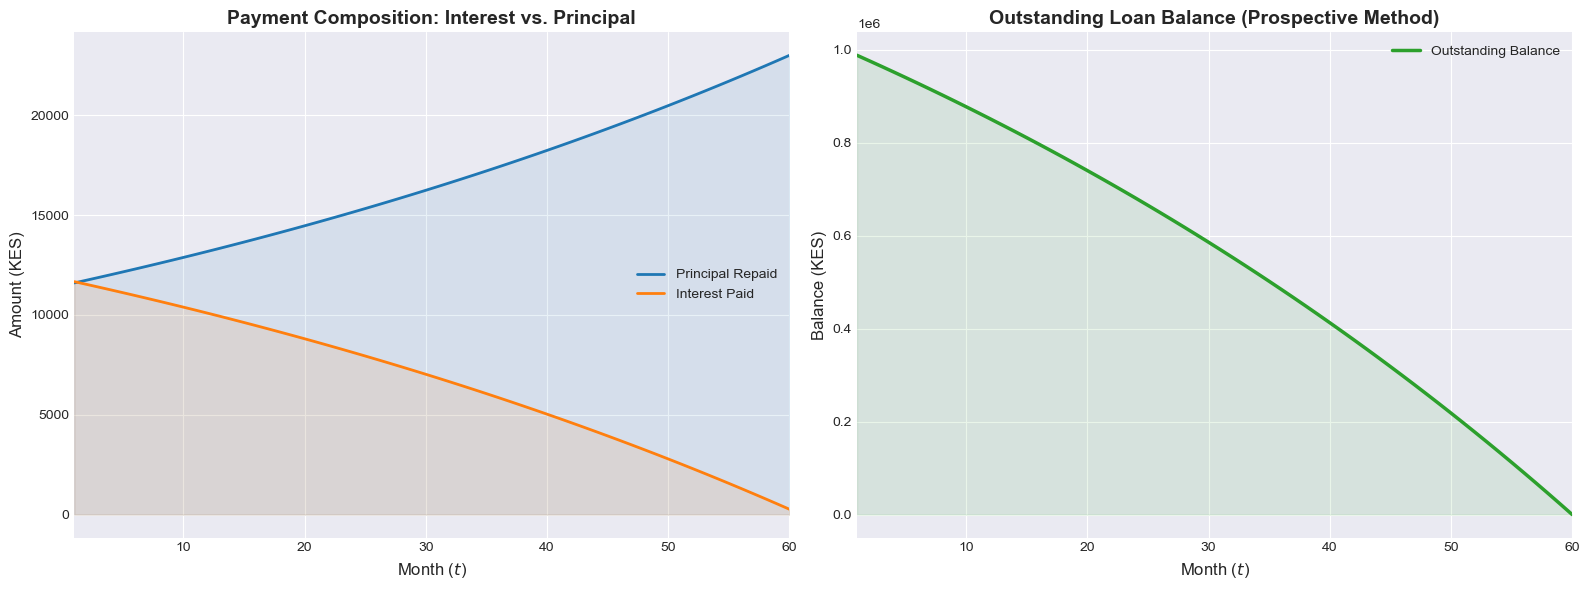

In [5]:
import matplotlib.pyplot as plt

# Set aesthetic styling
plt.style.use('seaborn-v0_8-darkgrid')

# ARCHITECTURE CHANGE: 1 row, 2 columns, optimized figsize for widescreen UI
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Principal vs Interest composition over time ---
ax1.plot(amortization_schedule['Month'], amortization_schedule['Principal_Repaid'], 
         label='Principal Repaid', color='#1f77b4', linewidth=2)
ax1.plot(amortization_schedule['Month'], amortization_schedule['Interest_Paid'], 
         label='Interest Paid', color='#ff7f0e', linewidth=2)
ax1.fill_between(amortization_schedule['Month'], amortization_schedule['Principal_Repaid'], color='#1f77b4', alpha=0.1)
ax1.fill_between(amortization_schedule['Month'], amortization_schedule['Interest_Paid'], color='#ff7f0e', alpha=0.1)

ax1.set_title('Payment Composition: Interest vs. Principal', fontsize=14, fontweight='bold')
ax1.set_xlabel('Month ($t$)', fontsize=12) # Explicitly added for the left chart
ax1.set_ylabel('Amount (KES)', fontsize=12)
ax1.legend(loc='center right')
ax1.margins(x=0)

# --- Plot 2: Outstanding Balance Drawdown ---
ax2.plot(amortization_schedule['Month'], amortization_schedule['Outstanding_Balance'], 
         label='Outstanding Balance', color='#2ca02c', linewidth=2.5)
ax2.fill_between(amortization_schedule['Month'], amortization_schedule['Outstanding_Balance'], color='#2ca02c', alpha=0.1)

ax2.set_title('Outstanding Loan Balance (Prospective Method)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Month ($t$)', fontsize=12)
ax2.set_ylabel('Balance (KES)', fontsize=12)
ax2.legend(loc='upper right') # Adjusted to upper right to stay clear of the curve
ax2.margins(x=0)

plt.tight_layout()
plt.show()